#importing packages

In [ ]:
!pip install tensorflow

In [ ]:
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud
from nltk.stem import PorterStemmer
import numpy as np
from keras.utils import to_categorical
from sklearn.metrics import confusion_matrix
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Embedding, LSTM, Dense, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

Loading Data

In [ ]:
val_data = pd.read_csv('/content/drive/MyDrive/Dataset/validation.csv')
train_data = pd.read_csv('/content/drive/MyDrive/Dataset/training.csv')
test_data = pd.read_csv('/content/drive/MyDrive/Dataset/test.csv')

#Mounting Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#Prtint Data

In [ ]:
print("Validation data :",val_data.shape)
print("Train data :",train_data.shape)
print("Test data :",test_data.shape)

Validation data : (2000, 2)
Train data : (16000, 2)
Test data : (2000, 2)


Dividing Test Dataset

In simple terms, this code essentially splits the original test_data into two parts: the first 1000 rows are kept as test data, and the rest are moved to the validation data. Then, it prints out the shapes of the updated validation and test datasets.

In [ ]:
half_test_data = test_data.iloc[1000:]
test_data = test_data.iloc[:1000]

val_data = pd.concat([val_data, half_test_data], axis=0)

print("new Valid data :",val_data.shape)
print("new Test data :",test_data.shape)
print(test_data)

new Valid data : (3000, 2)
new Test data : (1000, 2)
                                                  text  label
0    im feeling rather rotten so im not very ambiti...      0
1            im updating my blog because i feel shitty      0
2    i never make her separate from me because i do...      0
3    i left with my bouquet of red and yellow tulip...      1
4      i was feeling a little vain when i did this one      0
..                                                 ...    ...
995  i feel less shy about exploring roles in more ...      4
996     i replied feeling strange at giving the orders      5
997  i chant the invocation and feel his force supp...      1
998  i feel like he moves sleep i am glad i enjoyed...      1
999  i am really hurt and i feel unimportant and th...      0

[1000 rows x 2 columns]


In [ ]:
train_data.head(5)

,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3


This code translates numerical labels representing emotions into their corresponding emotional names and adds them as a new column to the train_data DataFrame. This makes it easier to understand the emotional context of each data point in the training dataset.

In [ ]:
labels_dict = {0:'sadness', 1:'joy', 2:'love', 3:'anger', 4:'fear', 5:'surprise'}
train_data['label_name'] = train_data['label'].map(labels_dict)
train_data.head()

,text,label,label_name
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


In [ ]:
train_data.groupby(["label_name","label"]).size()

label_name  label
anger       3        2159
fear        4        1937
joy         1        5362
love        2        1304
sadness     0        4666
surprise    5         572
dtype: int64

<Axes: xlabel='label_name'>

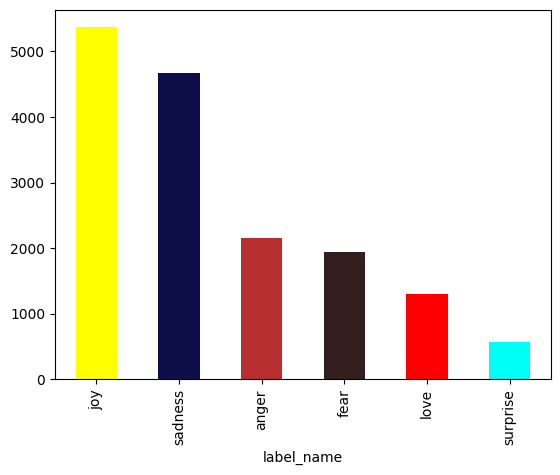

In [ ]:
train_data["label_name"].value_counts().plot(kind='bar',color=['yellow', '#0c0d49', '#b82f2f', '#331e1e', 'red','#00fff7'])

Data Cleaning

In [ ]:
print(train_data.isnull().sum())
print(val_data.isnull().sum())
print(test_data.isnull().sum())

text          0
label         0
label_name    0
dtype: int64
text     0
label    0
dtype: int64
text     0
label    0
dtype: int64


This statement concatenates the 'text' column from three different DataFrames (train_data, test_data, and val_data) into a single list called all_list. It works by using the tolist() method to convert each 'text' column into a Python list, and then using the + operator to concatenate these lists together. The result is a single list containing all the text data from the three DataFrames combined.

In [ ]:
all_list = train_data['text'].tolist() + test_data['text'].tolist() + val_data['text'].tolist()

The importance of this code lies in understanding the impact of stemming on the vocabulary size. Stemming reduces words to their base form, which can help in reducing the dimensionality of the feature space and improving computational efficiency, especially in natural language processing tasks like text classification or sentiment analysis. By comparing the number of words before and after stemming, you can observe the extent to which stemming reduces redundancy and variation in the vocabulary.

This line stems each word in the vocabulary (word_index1.keys()) using the **Porter stemmer** and stores the stemmed words in the list stemmed_words.

In [ ]:
tokenizer1 = Tokenizer()
tokenizer1.fit_on_texts(all_list)
word_index1 = tokenizer1.word_index

print("Number of words without Stemming:",len(word_index1))

stemmer = PorterStemmer()
stemmed_words = [stemmer.stem(word) for word in word_index1.keys()]

tokenizer2 = Tokenizer()
tokenizer2.fit_on_texts(stemmed_words)
word_index2 = tokenizer2.word_index

print("Number of words with Stemming:",len(word_index2))

Number of words without Stemming: 17096
Number of words with Stemming: 11705


In simple terms, this function takes each text in the DataFrame, splits it into words, reduces each word to its base form (stemming), converts these stemmed words into sequences of integers using a tokenizer, and pairs each sequence with its corresponding label. This is typically done to prepare text data for machine learning models, where words need to be represented as numerical values.

In [ ]:
def preprocess_data(data):
    new_data = []
    for index, row in data.iterrows():
        test_split = row['text'].split()
        stemmed_words2 = [stemmer.stem(word) for word in test_split]
        token_list= tokenizer2.texts_to_sequences([stemmed_words2])[0]
        new_data.append([token_list,row['label']])
    return new_data

So, this code essentially demonstrates how the preprocess_data() function transforms the original text data in train_data into a format suitable for machine learning, where words are represented as sequences of integers and paired with their corresponding labels.

In [ ]:
new_train_data = preprocess_data(train_data)
print(train_data['text'][0])
print(new_train_data[0])
#print(train_data)
print(new_train_data)

i didnt feel humiliated
[[3198, 3265, 220, 665], 0]
[[[3198, 3265, 220, 665], 0], [[3198, 1281, 588, 3231, 220, 3204, 1391, 3200, 3204, 1457, 27, 3214, 3231, 581, 3258, 1309, 1290, 29, 3199, 3208, 3608], 0], [[3205, 888, 3202, 1446, 3200, 97, 3198, 220, 3371, 260], 3], [[3198, 3209, 3282, 220, 3432, 3211, 3201, 4554, 3198, 85, 583, 1273, 1276, 3208, 585, 1279, 3201, 4143], 2], [[3198, 3209, 220, 3529], 3], [[3236, 3225, 220, 3202, 3228, 281, 1351, 3325, 1312, 3277, 1273, 1277], 0], [[3236, 3225, 90, 3217, 6121, 3217, 221, 399, 702, 3199, 3236, 3960, 3636, 3202, 1313, 3721, 3207, 3198, 3253, 220, 84, 3204, 3349], 5], [[3198, 220, 3212, 264, 3211, 1291, 3212, 3202, 413, 3217, 3212, 1449, 3212, 3202, 1322, 1340, 3337], 4], [[3198, 579, 3225, 3210, 5004, 3206, 1322, 3198, 220, 1273, 5004, 1299, 63, 1307, 3199, 3261, 3202, 1495, 2242], 1], [[3198, 220, 1417, 3247], 2], [[3198, 220, 84, 3198, 579, 3200, 587, 3201, 120, 3198, 3243, 591, 245, 1294], 0], [[3198, 582, 220, 1273, 629, 3208, 3202,

This code segment performs the same preprocessing steps on the validation dataset (val_data) as it did on the training dataset (train_data). It's a way to prepare the validation data for machine learning tasks, similar to how the training data was prepared.

In [ ]:
new_val_data = preprocess_data(val_data)
print(val_data['text'][0])
print(new_val_data[0])
#print(val_data)
#print(new_val_data)

im feeling quite sad and sorry for myself but ill snap out of it soon
[[3205, 220, 595, 1335, 3199, 3326, 3206, 3227, 3207, 1326, 518, 1283, 1274, 1276, 3380], 0]


This code segment prepares the training data for machine learning tasks by splitting it into the features (train_X), which are the tokenized sequences of words, and the labels (train_y), which indicate the corresponding categories or classes. These lists are then ready to be used as inputs for training machine learning models.

In [ ]:
# Splitting into train_X and train_y
train_X = [row[0] for row in new_train_data]
train_y = [row[1] for row in new_train_data]

# Print the results
print("train_X:", train_X[0])
print("train_y:", train_y[0])

train_X: [3198, 3265, 220, 665]
train_y: 0


For Validation

In [ ]:
val_X = [row[0] for row in new_val_data]
val_y = [row[1] for row in new_val_data]

print("train_X:", val_X[0])
print("train_y:", val_y[0])

train_X: [3205, 220, 595, 1335, 3199, 3326, 3206, 3227, 3207, 1326, 518, 1283, 1274, 1276, 3380]
train_y: 0


This code snippet helps in understanding the data by providing insights into the length and content of the longest sequence in the training dataset. This information is useful for various purposes, such as determining the maximum sequence length for padding or understanding the distribution of text lengths in the dataset.

In [ ]:
length_of_longest_sentence = len(max(train_X, key=len))
print(length_of_longest_sentence)
print(max(train_X, key=len))

66
[3198, 613, 3250, 3588, 3217, 3204, 3198, 927, 3245, 1497, 3245, 1354, 3217, 3245, 1303, 1296, 3200, 2107, 1284, 1276, 3220, 220, 3598, 3213, 220, 1276, 3528, 3217, 7890, 4263, 3221, 5569, 1552, 3243, 3198, 4263, 3221, 1552, 5570, 5570, 3198, 3579, 5569, 3198, 7891, 1276, 3200, 3202, 1293, 3219, 1401, 3948, 3598, 3213, 3223, 239, 3528, 3213, 85, 3267, 579, 1658, 3206, 3201, 239, 1289]


 This code segment performs padding on the sequences in train_X to ensure they have the same length, which is essential for processing them in machine learning models.

In [ ]:
for i in range(len(train_X)):
    for j in range(length_of_longest_sentence-len(train_X[i])):
        train_X[i].append(0)

for i in range(len(val_X)):
    for j in range(length_of_longest_sentence-len(val_X[i])):
        val_X[i].append(0)

In [ ]:
train_X = np.array(train_X)
train_y = np.array(train_y)
val_X = np.array(val_X)
val_y = np.array(val_y)
print(train_X,train_y)
print(val_X,val_y)
print(train_X.shape,train_y.shape)
print(val_X.shape,val_y.shape)

[[3198 3265  220 ...    0    0    0]
 [3198 1281  588 ...    0    0    0]
 [3205  888 3202 ...    0    0    0]
 ...
 [3198  220 3328 ...    0    0    0]
 [3198  220   84 ...    0    0    0]
 [3198  583 3202 ...    0    0    0]] [0 0 3 ... 1 3 0]
[[3205  220  595 ...    0    0    0]
 [3198  220   84 ...    0    0    0]
 [3198  220   84 ...    0    0    0]
 ...
 [3198  220 1273 ...    0    0    0]
 [3205  220 3219 ...    0    0    0]
 [3198  220 1280 ...    0    0    0]] [0 0 2 ... 1 1 4]
(16000, 66) (16000,)
(3000, 66) (3000,)


In [ ]:
# Convert labels to one-hot encoding
train_y_one_hot = to_categorical(train_y, num_classes=16000)
val_y_one_hot = to_categorical(val_y, num_classes=16000)

In [ ]:
model = Sequential()
model.add(Embedding(16000, 100, input_length=66))
model.add(Bidirectional(LSTM(150)))
model.add(Dense(16000, activation='softmax'))
adam = Adam(learning_rate=0.01)  # Replace lr with learning_rate
model.compile(loss='categorical_crossentropy', optimizer=adam, metrics=['accuracy'])
history = model.fit(train_X, train_y_one_hot, epochs=25, verbose=1, validation_data=(val_X, val_y_one_hot))
#print model.summary()
print(model)

Epoch 1/25
500/500 [==============================] - 179s 351ms/step - loss: 1.7490 - accuracy: 0.3078 - val_loss: 1.6469 - val_accuracy: 0.3540
Epoch 2/25
500/500 [==============================] - 182s 363ms/step - loss: 1.6671 - accuracy: 0.3294 - val_loss: 1.5484 - val_accuracy: 0.3550
Epoch 3/25
500/500 [==============================] - 171s 342ms/step - loss: 1.3046 - accuracy: 0.5184 - val_loss: 1.1105 - val_accuracy: 0.6027
Epoch 4/25
500/500 [==============================] - 176s 351ms/step - loss: 0.8683 - accuracy: 0.6842 - val_loss: 0.6952 - val_accuracy: 0.7557
Epoch 5/25
500/500 [==============================] - 175s 349ms/step - loss: 0.5355 - accuracy: 0.8123 - val_loss: 0.5287 - val_accuracy: 0.8257
Epoch 6/25
500/500 [==============================] - 178s 356ms/step - loss: 0.3963 - accuracy: 0.8581 - val_loss: 0.4721 - val_accuracy: 0.8380
Epoch 7/25
500/500 [==============================] - 171s 343ms/step - loss: 0.3377 - accuracy: 0.8791 - val_loss: 0.4501 -

#result and test

In [ ]:
#print the last training accuracy
last_accuracy = "{:.3f}".format(history.history['accuracy'][-1])
print("Training Accuracy:", last_accuracy)

#print the last validation accuracy
last_val_accuracy = "{:.3f}".format(history.history['val_accuracy'][-1])
print("Validation Accuracy:", last_val_accuracy)

#print the last training loss
last_loss = "{:.3f}".format(history.history['loss'][-1])
print("Training Loss:", last_loss)

#print the last validation loss
last_val_loss = "{:.3f}".format(history.history['val_loss'][-1])
print("Validation Loss:", last_val_loss)

Training Accuracy: 0.948
Validation Accuracy: 0.862
Training Loss: 0.142
Validation Loss: 0.501


In [ ]:

# Save the trained model in native Keras format
model.save("trainmodel.keras")


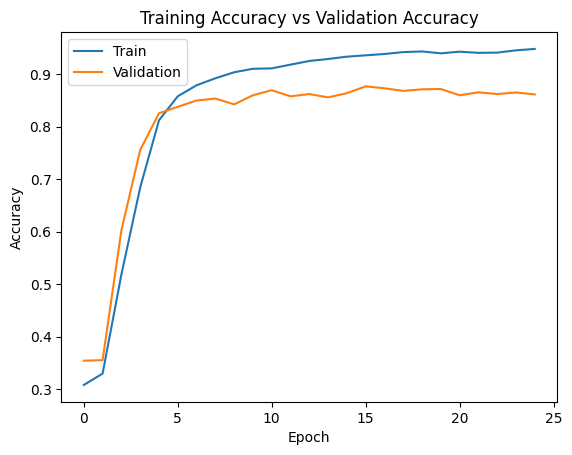

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Training Accuracy vs Validation Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

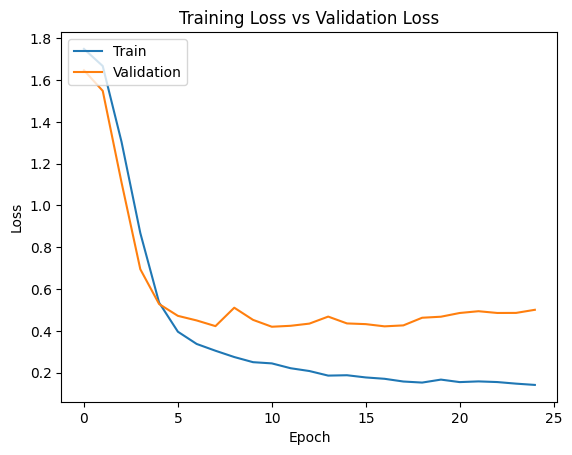

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Training Loss vs Validation Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In summary, this function preprocesses a single text input by tokenizing it, stemming the words, and padding it to match the length of the longest sequence observed during training. The resulting sequence of integers can be used as input to a machine learning model for prediction or classification.

In [ ]:
def get_text(text):
    tokenizer3 = Tokenizer()
    tokenizer3.fit_on_texts(text)
    word_index3 = tokenizer3.word_index

    stemmed_wordss = [stemmer.stem(word) for word in word_index3.keys()]

    tokens_list= tokenizer2.texts_to_sequences([stemmed_wordss])[0]

    for i in range(len(tokens_list)):
        for j in range(length_of_longest_sentence-len(tokens_list)):
            tokens_list.append(0)
    return tokens_list

In [ ]:
for _ in range(15):
    random_number = random.randint(0, 1000)
    num_to_predicte = random_number

    test = get_text([test_data['text'][num_to_predicte]])

    test = np.array(test)
    test = test.reshape(1, len(test))

    # Make predictions
    predictions = model.predict(test)

    predicted_class = np.argmax(predictions)
    print()
    print('Random value = ',random_number)
    print("Predicted Class:", predicted_class,labels_dict.get(predicted_class))
    print("Actual Class:", test_data['label'][num_to_predicte])
    print('Text : ',test_data['text'][num_to_predicte])
    print()

1/1 [==============================] - 1s 1s/step

Random value =  251
Predicted Class: 0 sadness
Actual Class: 0
Text :  i hope everyone can help with charity work without feeling stressed about such things

1/1 [==============================] - 0s 56ms/step

Random value =  329
Predicted Class: 0 sadness
Actual Class: 0
Text :  i just got up from a nap feeling really rotten so exhausted that i feel like i could just wilt onto the floor just sitting here

1/1 [==============================] - 0s 55ms/step

Random value =  4
Predicted Class: 0 sadness
Actual Class: 0
Text :  i was feeling a little vain when i did this one

1/1 [==============================] - 0s 55ms/step

Random value =  348
Predicted Class: 4 fear
Actual Class: 4
Text :  i still feel scared every time i go into a strange place

1/1 [==============================] - 0s 53ms/step

Random value =  424
Predicted Class: 0 sadness
Actual Class: 0
Text :  im going through life feeling now rather than being totally numb

In [ ]:
new_test_data=preprocess_data(test_data)

test_X = [row[0] for row in new_train_data]
test_y = [row[1] for row in new_train_data]

for i in range(len(test_X)):
    for j in range(length_of_longest_sentence-len(test_X[i])):
        test_X[i].append(0)

test_X = np.array(test_X)
test_y = np.array(test_y)

test_y_one_hot = to_categorical(test_y, num_classes=16000)

In [ ]:
y_pred = model.predict(test_X)
y_pred_classes = np.argmax(y_pred, axis=1)

500/500 [==============================] - 42s 84ms/step


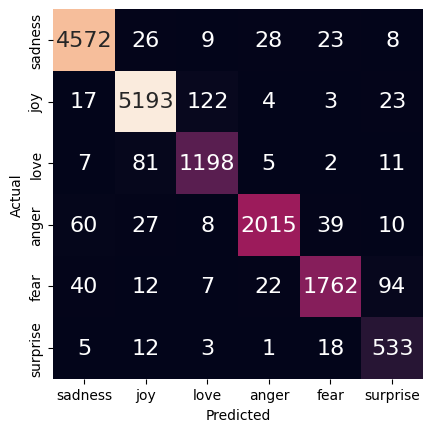

In [ ]:
y_true_labels = np.argmax(test_y_one_hot, axis=1)

labels=['sadness','joy','love','anger','fear','surprise']
#labels = list(set(labels).intersection(set(np.unique(y_true_labels)).union(set(np.unique(y_pred_classes)))))

cm = confusion_matrix(y_true_labels, y_pred_classes)
df_cm = pd.DataFrame(cm, labels, labels)
ax = sns.heatmap(df_cm, annot=True, annot_kws={'size': 16}, square=True, cbar=False, fmt='g')
ax.set_ylim(0, 6)
plt.xlabel('Predicted')
plt.ylabel('Actual')
ax.invert_yaxis()
plt.show()

In [ ]:
import pickle
with open('/content/drive/My Drive/trainmodel.pkl', 'wb') as file:
    pickle.dump(model, file)

In [ ]:
'''txt=input("enter the text : ")
test = get_text(txt)
test = np.array(test)
test = test.reshape(1, len(test))

    # Make predictions
predictions = model.predict(test)

predicted_class = np.argmax(predictions)
print("Predicted Class:", predicted_class,labels_dict.get(predicted_class))'''


'txt=input("enter the text : ")\ntest = get_text(txt)\ntest = np.array(test)\ntest = test.reshape(1, len(test))\n\n    # Make predictions\npredictions = model.predict(test)\n\npredicted_class = np.argmax(predictions)\nprint("Predicted Class:", predicted_class,labels_dict.get(predicted_class))'